<a href="https://www.kaggle.com/code/sonawanelalitsunil/indian-food-ml-74?scriptVersionId=238499050" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-food-dataset/IndianFoodDataset.csv


## Title: Indian Food Dataset

## Description: 
A comprehensive dataset featuring traditional Indian dishes, including ingredients, preparation methods, regional origins, and dietary information. Ideal for culinary analysis, recipe recommendation, and cultural food studies.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/indian-food-dataset/IndianFoodDataset.csv')

In [3]:
df.head()

,Srno,RecipeName,TranslatedRecipeName,Ingredients,TranslatedIngredients,PrepTimeInMins,CookTimeInMins,TotalTimeInMins,Servings,Cuisine,Course,Diet,Instructions,TranslatedInstructions,URL,ComplexityLevel,MainIngredient
0,1,Masala Karela Recipe,Masala Karela Recipe,"6 Karela (Bitter Gourd/ Pavakkai) - deseeded,S...","6 Karela (Bitter Gourd/ Pavakkai) - deseeded,S...",15,30,45,6,Indian,Side Dish,Diabetic Friendly,"To begin making the Masala Karela Recipe,de-se...","To begin making the Masala Karela Recipe,de-se...",https://www.archanaskitchen.com/masala-karela-...,Hard,deseeded
1,2,टमाटर पुलियोगरे रेसिपी - Spicy Tomato Rice (Re...,Spicy Tomato Rice (Recipe),"2-1/2 कप चावल - पका ले,3 टमाटर,3 छोटा चमच्च बी...","2-1 / 2 cups rice - cooked, 3 tomatoes, 3 teas...",5,10,15,3,South Indian Recipes,Main Course,Vegetarian,टमाटर पुलियोगरे बनाने के लिए सबसे पहले टमाटर क...,"To make tomato puliogere, first cut the tomato...",http://www.archanaskitchen.com/spicy-tomato-ri...,Hard,cooked
2,3,Ragi Semiya Upma Recipe - Ragi Millet Vermicel...,Ragi Semiya Upma Recipe - Ragi Millet Vermicel...,"1-1/2 cups Rice Vermicelli Noodles (Thin),1 On...","1-1/2 cups Rice Vermicelli Noodles (Thin),1 On...",20,30,50,4,South Indian Recipes,South Indian Breakfast,High Protein Vegetarian,"To begin making the Ragi Vermicelli Recipe, fi...","To begin making the Ragi Vermicelli Recipe, fi...",http://www.archanaskitchen.com/ragi-vermicelli...,Hard,(Thin)
3,4,Gongura Chicken Curry Recipe - Andhra Style Go...,Gongura Chicken Curry Recipe - Andhra Style Go...,"500 grams Chicken,2 Onion - chopped,1 Tomato -...","500 grams Chicken,2 Onion - chopped,1 Tomato -...",15,30,45,4,Andhra,Lunch,Non Vegeterian,To begin making Gongura Chicken Curry Recipe f...,To begin making Gongura Chicken Curry Recipe f...,http://www.archanaskitchen.com/gongura-chicken...,Hard,Chicken
4,5,आंध्रा स्टाइल आलम पचड़ी रेसिपी - Adrak Chutney ...,Andhra Style Alam Pachadi Recipe - Adrak Chutn...,"1 बड़ा चमच्च चना दाल,1 बड़ा चमच्च सफ़ेद उरद दाल,2...","1 tablespoon chana dal, 1 tablespoon white ura...",10,20,30,4,Andhra,South Indian Breakfast,Vegetarian,आंध्रा स्टाइल आलम पचड़ी बनाने के लिए सबसे पहले ...,"To make Andhra Style Alam Pachadi, first heat ...",https://www.archanaskitchen.com/andhra-style-a...,Hard,dal


In [4]:
df.tail()

,Srno,RecipeName,TranslatedRecipeName,Ingredients,TranslatedIngredients,PrepTimeInMins,CookTimeInMins,TotalTimeInMins,Servings,Cuisine,Course,Diet,Instructions,TranslatedInstructions,URL,ComplexityLevel,MainIngredient
6866,14073,गोअन मशरुम जकुटी रेसिपी - Goan Mushroom Xacuti...,Goan Mushroom Xacuti Recipe,"20 बटन मशरुम,2 प्याज - काट ले,1 टमाटर - बारीक ...","20 बटन मशरुम,2 प्याज - काट ले,1 टमाटर - बारीक ...",15,45,60,4,Goan Recipes,Lunch,Vegetarian,गोअन मशरुम जकुटी रेसिपी बनाने के लिए सबसे पहले...,गोअन मशरुम जकुटी रेसिपी बनाने के लिए सबसे पहले...,https://www.archanaskitchen.com/goan-mushroom-...,Hard,मशरुम
6867,14107,शकरकंदी और मेथी का पराठा रेसिपी - Sweet Potato...,Sweet Potato & Methi Stuffed Paratha Recipe,"1 बड़ा चम्मच तेल,1 कप गेहूं का आटा,नमक - स्वाद ...","1 बड़ा चम्मच तेल,1 कप गेहूं का आटा,नमक - स्वाद ...",30,60,90,4,North Indian Recipes,North Indian Breakfast,Diabetic Friendly,शकरकंदी और मेथी का पराठा रेसिपी बनाने के लिए स...,शकरकंदी और मेथी का पराठा रेसिपी बनाने के लिए स...,https://www.archanaskitchen.com/sweet-potato-m...,Hard,तेल
6868,14165,Ullikadala Pulusu Recipe | Spring Onion Curry,Ullikadala Pulusu Recipe | Spring Onion Curry,150 grams Spring Onion (Bulb & Greens) - chopp...,150 grams Spring Onion (Bulb & Greens) - chopp...,5,10,15,2,Andhra,Side Dish,Vegetarian,To begin making Ullikadala Pulusu Recipe | Spr...,To begin making Ullikadala Pulusu Recipe | Spr...,https://www.archanaskitchen.com/ullikadala-pul...,Hard,chopped
6869,14167,Kashmiri Style Kokur Yakhni Recipe-Chicken Coo...,Kashmiri Style Kokur Yakhni Recipe-Chicken Coo...,"1 kg Chicken - medium pieces,1/2 cup Mustard o...","1 kg Chicken - medium pieces,1/2 cup Mustard o...",30,45,75,4,Kashmiri,Lunch,Non Vegeterian,To begin making the Kashmiri Kokur Yakhni reci...,To begin making the Kashmiri Kokur Yakhni reci...,http://www.archanaskitchen.com/kashmiri-kokur-...,Hard,pieces
6870,14211,नवरंग दाल रेसिपी - Navrang Dal Recipe,Navrang Dal Recipe,"2 बड़े चम्मच हरी मूंग दाल,2 बड़े चम्मच सफ़ेद उरद ...","2 बड़े चम्मच हरी मूंग दाल,2 बड़े चम्मच सफ़ेद उरद ...",10,30,40,4,North Indian Recipes,Lunch,High Protein Vegetarian,नवरंग दाल रेसिपी बनाने के लिए सबसे पहले सारी ...,नवरंग दाल रेसिपी बनाने के लिए सबसे पहले सारी ...,https://www.archanaskitchen.com/navrang-dal-re...,Hard,दाल


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6871 entries, 0 to 6870
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Srno                    6871 non-null   int64 
 1   RecipeName              6871 non-null   object
 2   TranslatedRecipeName    6871 non-null   object
 3   Ingredients             6865 non-null   object
 4   TranslatedIngredients   6865 non-null   object
 5   PrepTimeInMins          6871 non-null   int64 
 6   CookTimeInMins          6871 non-null   int64 
 7   TotalTimeInMins         6871 non-null   int64 
 8   Servings                6871 non-null   int64 
 9   Cuisine                 6871 non-null   object
 10  Course                  6871 non-null   object
 11  Diet                    6871 non-null   object
 12  Instructions            6871 non-null   object
 13  TranslatedInstructions  6871 non-null   object
 14  URL                     6871 non-null   object
 15  Comp

In [6]:
df.describe()

,Srno,PrepTimeInMins,CookTimeInMins,TotalTimeInMins,Servings
count,6871.000000,6871.000000,6871.000000,6871.000000,6871.000000
mean,4902.979042,28.585213,30.832339,59.417552,5.611410
std,3479.531022,81.042007,34.019694,88.699940,26.221807
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1955.500000,10.000000,20.000000,30.000000,4.000000
50%,4304.000000,15.000000,30.000000,40.000000,4.000000
75%,7363.000000,20.000000,35.000000,55.000000,4.000000
max,14211.000000,2880.000000,900.000000,2925.000000,1000.000000


In [7]:
df.isnull().sum()

Srno                      0
RecipeName                0
TranslatedRecipeName      0
Ingredients               6
TranslatedIngredients     6
PrepTimeInMins            0
CookTimeInMins            0
TotalTimeInMins           0
Servings                  0
Cuisine                   0
Course                    0
Diet                      0
Instructions              0
TranslatedInstructions    0
URL                       0
ComplexityLevel           0
MainIngredient            6
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Srno                       int64
RecipeName                object
TranslatedRecipeName      object
Ingredients               object
TranslatedIngredients     object
PrepTimeInMins             int64
CookTimeInMins             int64
TotalTimeInMins            int64
Servings                   int64
Cuisine                   object
Course                    object
Diet                      object
Instructions              object
TranslatedInstructions    object
URL                       object
ComplexityLevel           object
MainIngredient            object
dtype: object

In [10]:
df.shape

(6871, 17)

In [11]:
df.columns

Index(['Srno', 'RecipeName', 'TranslatedRecipeName', 'Ingredients',
       'TranslatedIngredients', 'PrepTimeInMins', 'CookTimeInMins',
       'TotalTimeInMins', 'Servings', 'Cuisine', 'Course', 'Diet',
       'Instructions', 'TranslatedInstructions', 'URL', 'ComplexityLevel',
       'MainIngredient'],
      dtype='object')

## Data visualizations

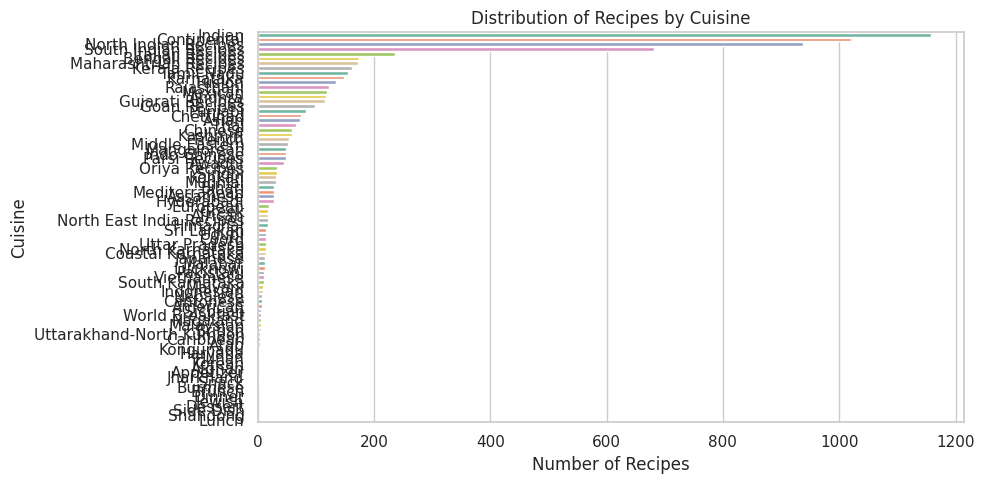

In [12]:
# Set style
sns.set(style="whitegrid")

# Plot 1: Cuisine
plt.figure(figsize=(10, 5))
sns.countplot(y='Cuisine', data=df, order=df['Cuisine'].value_counts().index, palette='Set2')
plt.title('Distribution of Recipes by Cuisine')
plt.xlabel('Number of Recipes')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

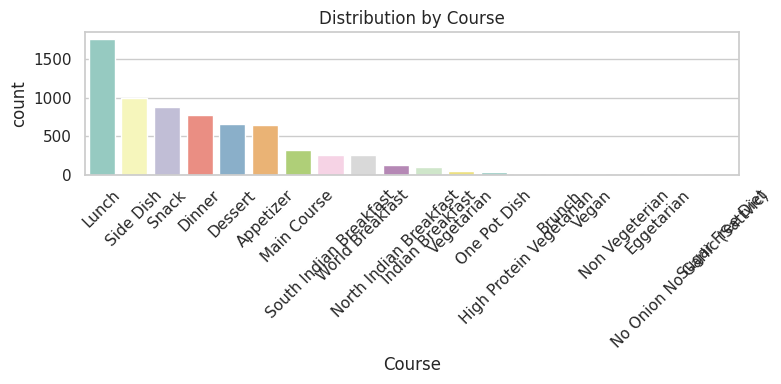

In [13]:
# Plot 2: Course
plt.figure(figsize=(8, 4))
sns.countplot(x='Course', data=df, order=df['Course'].value_counts().index, palette='Set3')
plt.title('Distribution by Course')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

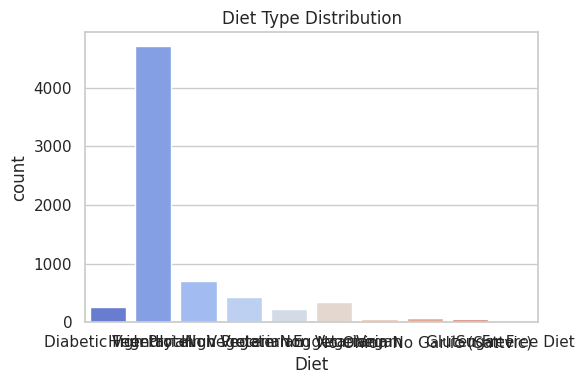

In [14]:
# Plot 3: Diet
plt.figure(figsize=(6, 4))
sns.countplot(x='Diet', data=df, palette='coolwarm')
plt.title('Diet Type Distribution')
plt.tight_layout()
plt.show()

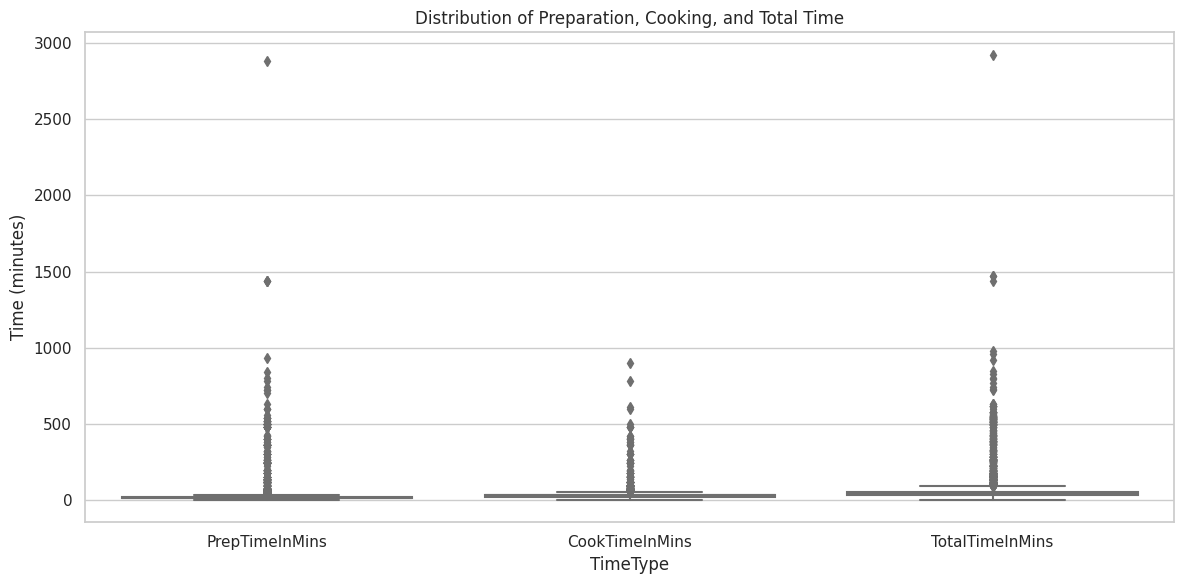

In [15]:
# Prep Time, Cook Time, Total Time (Box Plot)
plt.figure(figsize=(12, 6))
df_long = df.melt(value_vars=['PrepTimeInMins', 'CookTimeInMins', 'TotalTimeInMins'], 
                  var_name='TimeType', value_name='Time')
sns.boxplot(x='TimeType', y='Time', data=df_long, palette='pastel')
plt.title('Distribution of Preparation, Cooking, and Total Time')
plt.ylabel('Time (minutes)')
plt.tight_layout()
plt.show()

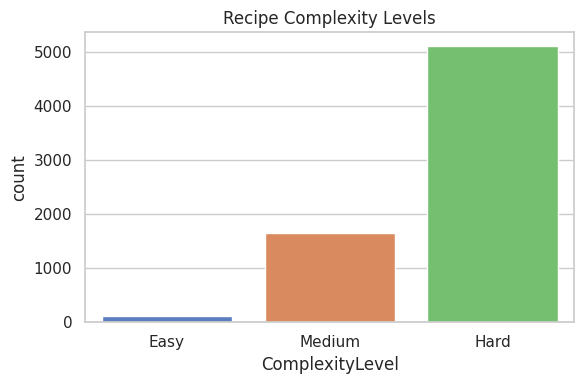

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x='ComplexityLevel', data=df, order=['Easy', 'Medium', 'Hard'], palette='muted')
plt.title('Recipe Complexity Levels')
plt.tight_layout()
plt.show()

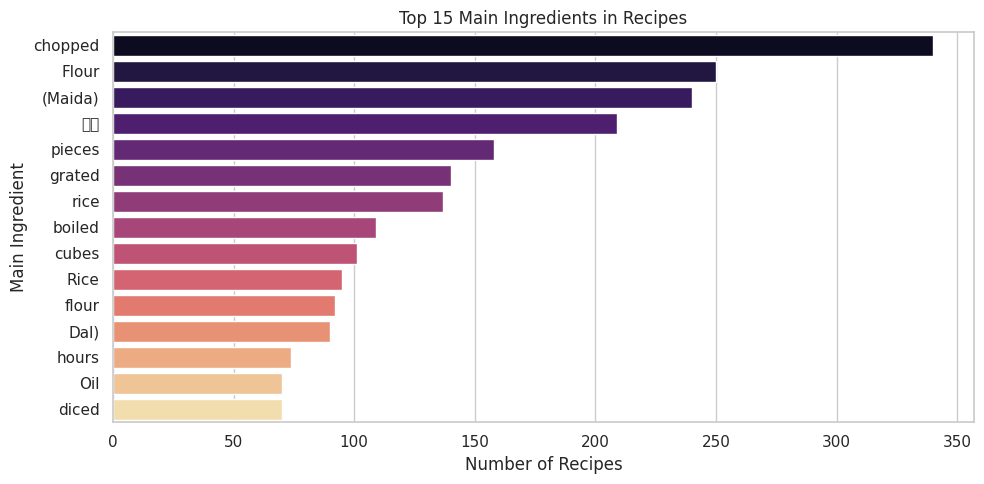

In [17]:
top_ingredients = df['MainIngredient'].value_counts().nlargest(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_ingredients.values, y=top_ingredients.index, palette='magma')
plt.title('Top 15 Main Ingredients in Recipes')
plt.xlabel('Number of Recipes')
plt.ylabel('Main Ingredient')
plt.tight_layout()
plt.show()

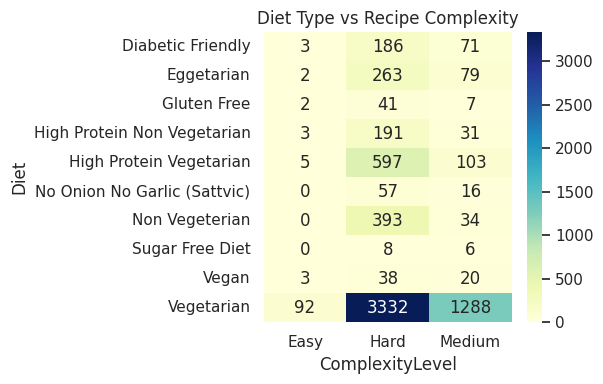

In [18]:
diet_complexity = pd.crosstab(df['Diet'], df['ComplexityLevel'])

plt.figure(figsize=(6, 4))
sns.heatmap(diet_complexity, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Diet Type vs Recipe Complexity')
plt.tight_layout()
plt.show()

In [19]:
import plotly.express as px

fig = px.sunburst(df, path=['Cuisine', 'Course', 'Diet'], 
                  values=None, title='Sunburst Chart of Cuisine → Course → Diet')
fig.show()

## Predictive modeling

In [20]:
# Drop rows with missing target or essential features
df = df.dropna(subset=['Diet', 'PrepTimeInMins', 'CookTimeInMins', 'TotalTimeInMins',
                       'ComplexityLevel', 'Cuisine', 'Course', 'MainIngredient'])

# Select features and target
features = ['PrepTimeInMins', 'CookTimeInMins', 'TotalTimeInMins',
            'Cuisine', 'Course', 'ComplexityLevel', 'MainIngredient']
target = 'Diet'

X = df[features]
y = df[target]

In [21]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Vegetarian=1, Non-Vegetarian=0 (or vice versa)

# Categorical and numeric split
categorical_cols = ['Cuisine', 'Course', 'ComplexityLevel', 'MainIngredient']
numeric_cols = ['PrepTimeInMins', 'CookTimeInMins', 'TotalTimeInMins']

# Column transformer
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
], remainder='passthrough')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)



▶️ Logistic Regression
Accuracy: 0.71


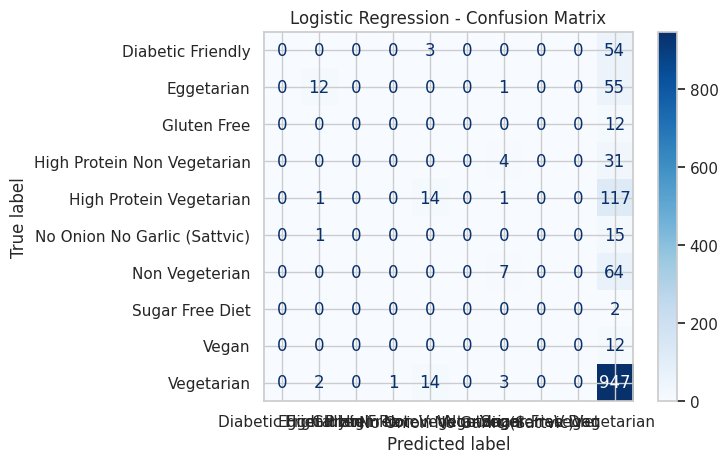


▶️ Decision Tree
Accuracy: 0.68


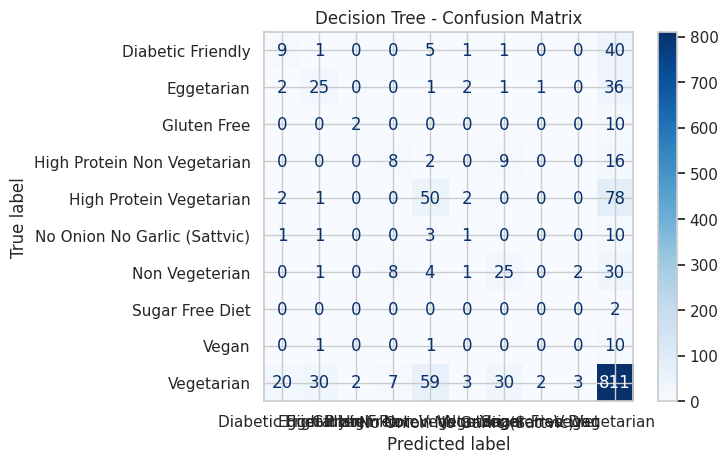


▶️ Random Forest
Accuracy: 0.74


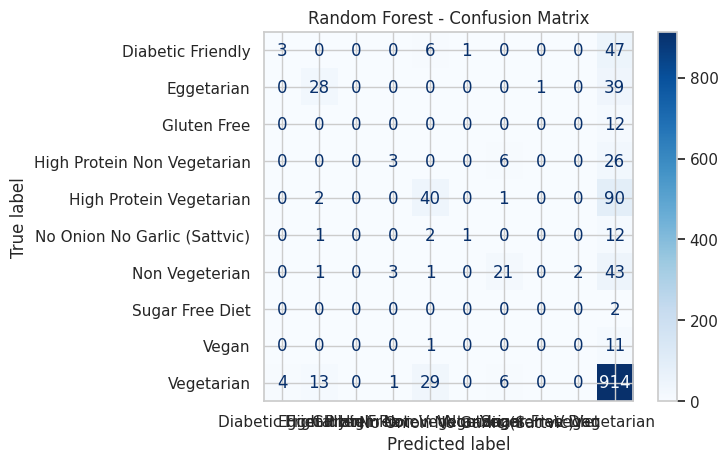


▶️ K-Nearest Neighbors
Accuracy: 0.65


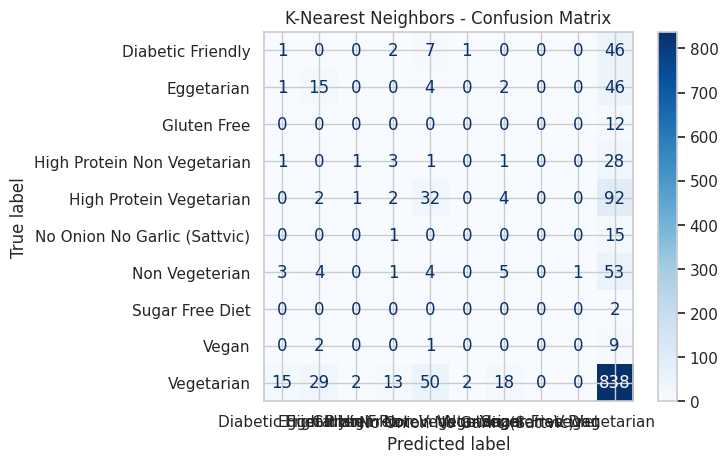


▶️ Naive Bayes
Accuracy: 0.19


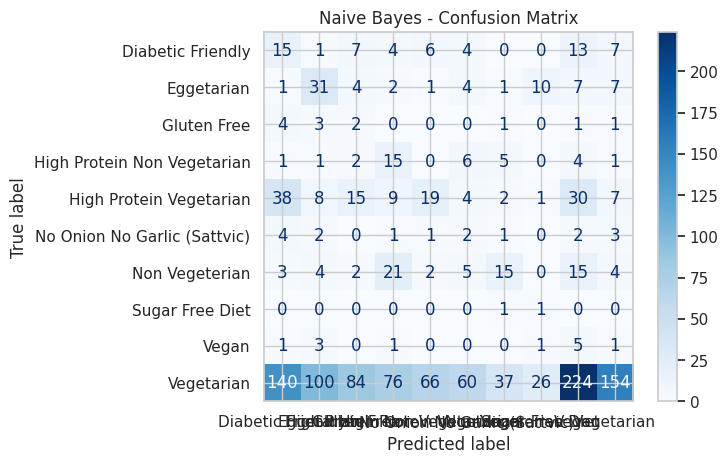


▶️ Support Vector Machine
Accuracy: 0.70


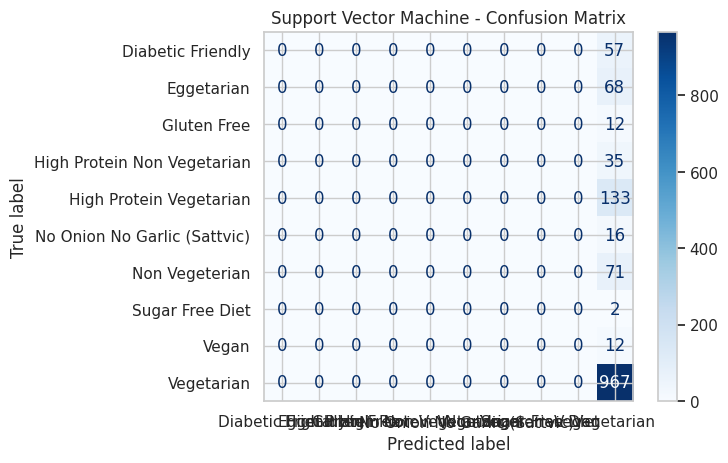

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC()
}

results = {}

for name, model in models.items():
    print(f"\n▶️ {name}")

    # Use dense output if model is GaussianNB
    use_dense = isinstance(model, GaussianNB)
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=not use_dense)

    preprocessor = ColumnTransformer([
        ('onehot', encoder, categorical_cols)
    ], remainder='passthrough')

    # Create pipeline
    clf = Pipeline(steps=[('preprocess', preprocessor), ('model', model)])
    
    # Train
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"Accuracy: {acc:.2f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()


In [23]:
# Sort and print results
print("\n📊 Accuracy Summary:")
for model_name, accuracy in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name}: {accuracy:.2f}")



📊 Accuracy Summary:
Random Forest: 0.74
Logistic Regression: 0.71
Support Vector Machine: 0.70
Decision Tree: 0.68
K-Nearest Neighbors: 0.65
Naive Bayes: 0.19


## Thank you..pls upvote!!!!